# Ropedia Academy — C9 · Paper deep-dive & reproducing a model

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChaoYue0307/ropedia-academy/blob/main/notebooks/C9.ipynb)

> **Trains a frozen-feature baseline with a shuffle-control ablation and plots top-1/top-5 against the control and chance to prove the metric is real.**
>
> 训练冻结特征基线并做打乱对照消融，画出 top-1/top-5 与对照、随机水平的对比，证明指标可信。

This is the lesson's core example — **self-contained and runnable end to end**. It builds toy tensors, performs the lesson's key computation, and **visualizes the result with matplotlib** (the plot renders inline below the cell), so you learn the concept by executing and *seeing* it.

Colab's default runtime already includes `torch`, `numpy`, `networkx`, and `matplotlib`, so just press **Run all** — every cell goes green and a figure appears. Sizes are shrunk to run on CPU; swap in a real batch and the same code scales up.

🔗 Full lesson (with the interactive demo & key terms): https://chaoyue0307.github.io/ropedia-academy/lesson/C9

top-1=1.00 top-5=1.00 | shuffled control=0.05 (~chance 0.05)


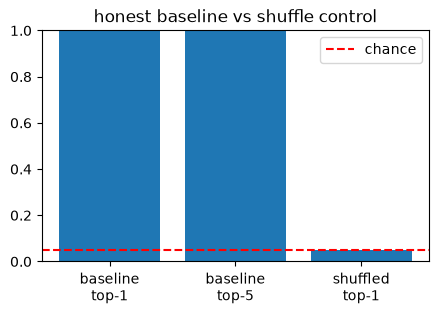

In [1]:
import torch, torch.nn as nn, torch.nn.functional as F, matplotlib.pyplot as plt
# Honest baseline: frozen features + a small head; a shuffle-control ablation.

# ---------- INPUT: frozen features (signal + noise) and labels, held-out split ----------
torch.manual_seed(0); N, D, K = 600, 256, 20
labels = torch.randint(0, K, (N,))
feats  = torch.randn(N, D) + F.one_hot(labels, K).float() @ torch.randn(K, D)
tr, te = slice(0,500), slice(500,N)

# ---------- MODEL: train a linear head (real features) + a shuffled control ----------
def train_head(x):
    head = nn.Linear(D, K); opt = torch.optim.Adam(head.parameters(), 1e-2)
    for _ in range(300):
        opt.zero_grad(); F.cross_entropy(head(x[tr]), labels[tr]).backward(); opt.step()
    return head
head = train_head(feats)
topk = lambda k: (head(feats[te]).topk(k,-1).indices == labels[te][:,None]).any(-1).float().mean().item()
shuf = train_head(feats[torch.randperm(N)])           # destroy the signal
acc_ctrl = (shuf(feats[te]).argmax(-1) == labels[te]).float().mean().item()

# ---------- OUTPUT: metrics + a bar chart vs the control and chance ----------
print(f"top-1={topk(1):.2f} top-5={topk(5):.2f} | shuffled control={acc_ctrl:.2f} (~chance {1/K:.2f})")
plt.figure(figsize=(5, 3))
plt.bar(["baseline\ntop-1","baseline\ntop-5","shuffled\ntop-1"], [topk(1), topk(5), acc_ctrl])
plt.axhline(1/K, ls='--', c='r', label='chance'); plt.ylim(0,1)
plt.title("honest baseline vs shuffle control"); plt.legend(); plt.show()

### Where to go next

- Swap the toy tensors for a real batch and watch the shapes flow through.
- Open the matching lesson for the math and an interactive figure: https://chaoyue0307.github.io/ropedia-academy/lesson/C9
- Browse every notebook: https://github.com/ChaoYue0307/ropedia-academy/tree/main/notebooks